# Social Media Sentiment & Engagement Analysis

## Project objective
Analyze how sentiment/emotional category, social-media platform, geography, posting time, hashtags, and text characteristics relate to social-media engagement.

### Analytical question
**How does sentiment relate to social-media engagement, and how does this relationship vary across platforms, countries, and time?**

### Workflow
1. Load & inspect
2. Remove unnecessary columns
3. Clean whitespace
4. Check data types
5. Check missing values
6. Check duplicates
7. Validate categories
8. Validate numerical values
9. Validate `Timestamp` against `Year`, `Month`, `Day`, and `Hour`
10. Investigate outliers
11. Create `Total_Engagement`
12. Clean/transform hashtags
13. Prepare text
14. EDA
15. Insights
16. Recommendations

> **Important:** The original dataset contains many detailed emotion labels (not only Positive/Negative/Neutral). The notebook preserves the original `Sentiment` label and creates a broader `Sentiment_Group` for analysis. The broader group is an analytical grouping, not a replacement for the source label.

## 1. Load & inspect

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

DATA_PATH = Path("data/Sentiment dataset.csv")

df_raw = pd.read_csv(DATA_PATH)

print("Shape:", df_raw.shape)
display(df_raw.head())
display(df_raw.info())
display(df_raw.describe(include="all").T)
df_raw

Shape: (732, 15)


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0.1,732.0,NaN,NaN,NaN,366.464481,211.513936,0.0,183.75,366.5,549.25,732.0
Unnamed: 0,732.0,NaN,NaN,NaN,369.740437,212.428936,0.0,185.75,370.5,553.25,736.0
Text,732,707,"A compassionate rain, tears of empathy falling gently, nurturing the seeds of kindness in the garden of human conne...",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sentiment,732,279,Positive,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Timestamp,732,683,2022-07-17 06:15:00,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
User,732,685,WindWhisperer,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Platform,732,4,Instagram,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hashtags,732,697,#Compassionate #TearsOfEmpathy,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Retweets,732.0,NaN,NaN,NaN,21.508197,7.061286,5.0,17.75,22.0,25.0,40.0
Likes,732.0,NaN,NaN,NaN,42.901639,14.089848,10.0,34.75,43.0,50.0,80.0


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,728,732,Collaborating on a science project that received recognition at a regional fair. Science triumphs and smiles!,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,8,18,18
728,729,733,"Attending a surprise birthday party organized by friends. Surrounded by love, laughter, and good company!",Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA,2018,6,22,14
729,730,734,Successfully fundraising for a school charity initiative. The joy of giving back to the community!,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,2019,4,5,17
730,731,735,"Participating in a multicultural festival, celebrating diversity with music, dance, and delicious food!",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,2020,2,29,20


## 2. Remove unnecessary columns

In [ ]:
# These are exported index columns and do not represent analytical variables.
unnecessary_cols = ["Unnamed: 0.1", "Unnamed: 0"]

df = df_raw.drop(columns=unnecessary_cols, errors="ignore").copy()

print("Removed:", [c for c in unnecessary_cols if c in df_raw.columns])
print("New shape:", df.shape)
display(df.head())
df

Removed: ['Unnamed: 0.1', 'Unnamed: 0']
New shape: (732, 13)


,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


## 3. Clean whitespace

In [40]:
# Strip leading/trailing whitespace from every text-like column.
string_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

for col in string_cols:
    df[col] = df[col].astype("string").str.strip()

# Treat empty strings as missing.
for col in string_cols:
    df[col] = df[col].replace(r"^\s*$", pd.NA, regex=True)

display(df.head())
print("String columns cleaned:", string_cols)

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


String columns cleaned: ['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Country']


## 4. Check and correct data types

In [41]:
# Convert Timestamp explicitly.
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

# Numeric columns should be numeric.
numeric_cols = ["Retweets", "Likes", "Year", "Month", "Day", "Hour"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.dtypes)

Text         string[python]
Sentiment    string[python]
Timestamp    datetime64[ns]
User         string[python]
Platform     string[python]
Hashtags     string[python]
Retweets            float64
Likes               float64
Country      string[python]
Year                  int64
Month                 int64
Day                   int64
Hour                  int64
dtype: object


## 5. Missing-value audit

In [42]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False)

display(missing)

# Do not drop rows automatically.
# Missing values should be handled according to their business meaning.

,missing_count,missing_percent
Text,0,0.0
Sentiment,0,0.0
Timestamp,0,0.0
User,0,0.0
Platform,0,0.0
Hashtags,0,0.0
Retweets,0,0.0
Likes,0,0.0
Country,0,0.0
Year,0,0.0


## 6. Duplicate audit

In [43]:
duplicate_count = df.duplicated().sum()
print("Exact duplicate rows:", duplicate_count)

if duplicate_count:
    display(df.loc[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(20))

# Exact duplicate rows are removed only after inspection.
df = df.drop_duplicates().copy()
print("Shape after exact-duplicate removal:", df.shape)

Exact duplicate rows: 22


,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
278,"A compassionate rain, tears of empathy falling gently, nurturing the seeds of kindness in the garden of human connec...",Compassionate,2021-07-01 12:10:00,RainNurturer,Instagram,#Compassionate #TearsOfEmpathy,21.0,42.0,Canada,2021,7,1,12
292,"A compassionate rain, tears of empathy falling gently, nurturing the seeds of kindness in the garden of human connec...",Compassionate,2021-07-01 12:10:00,RainNurturer,Instagram,#Compassionate #TearsOfEmpathy,21.0,42.0,Canada,2021,7,1,12
271,"A free spirit soaring on the wings of dreams, leaving trails of independence in the azure sky of boundless possibili...",Free-spirited,2020-06-10 10:05:00,DreamSoarer,Twitter,#FreeSpirit #WingsOfDreams,22.0,44.0,UK,2020,6,10,10
285,"A free spirit soaring on the wings of dreams, leaving trails of independence in the azure sky of boundless possibili...",Free-spirited,2020-06-10 10:05:00,DreamSoarer,Twitter,#FreeSpirit #WingsOfDreams,22.0,44.0,UK,2020,6,10,10
267,"A playful escapade in the carnival of life, carousel laughter and cotton candy dreams swirling in the joyous atmosph...",Playful,2018-08-22 17:20:00,CarnivalDreamer,Facebook,#Playful #CarnivalEscapade,24.0,48.0,Australia,2018,8,22,17
281,"A playful escapade in the carnival of life, carousel laughter and cotton candy dreams swirling in the joyous atmosph...",Playful,2018-08-22 17:20:00,CarnivalDreamer,Facebook,#Playful #CarnivalEscapade,24.0,48.0,Australia,2018,8,22,17
295,"A playful escapade in the carnival of life, carousel laughter and cotton candy dreams swirling in the joyous atmosph...",Playful,2018-08-22 17:20:00,CarnivalDreamer,Facebook,#Playful #CarnivalEscapade,24.0,48.0,Australia,2018,8,22,17
272,"Bathed in the golden hues of gratefulness, a sunset of appreciation casting its warm glow on the landscapes of the h...",Grateful,2022-04-01 18:30:00,SunsetAdmirer,Instagram,#Grateful #GoldenHues,19.0,38.0,Australia,2022,4,1,18
286,"Bathed in the golden hues of gratefulness, a sunset of appreciation casting its warm glow on the landscapes of the h...",Grateful,2022-04-01 18:30:00,SunsetAdmirer,Instagram,#Grateful #GoldenHues,19.0,38.0,Australia,2022,4,1,18
277,"Charting a course through the waves of hopeful anticipation, a sailor steering towards the shores of dreams yet unex...",Hopeful,2022-10-30 11:40:00,WaveNavigator,Twitter,#Hopeful #SailorOfDreams,17.0,34.0,Australia,2022,10,30,11


Shape after exact-duplicate removal: (710, 13)


## 7. Validate categorical variables

In [44]:
categorical_cols = ["Sentiment", "Platform", "Country"]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print("Unique:", df[col].nunique(dropna=True))
    display(df[col].value_counts(dropna=False).head(30))


--- Sentiment ---
Unique: 191


Sentiment
Positive         45
Joy              44
Excitement       37
Contentment      18
Neutral          18
Gratitude        17
Curiosity        16
Serenity         15
Happy            14
Despair          11
Nostalgia        11
Awe               9
Sad               9
Grief             9
Loneliness        8
Confusion         8
Embarrassed       8
Acceptance        8
Elation           7
Pride             7
Enthusiasm        7
Euphoria          7
Determination     7
Regret            6
Surprise          6
Bad               6
Hate              6
Melancholy        6
Hopeful           6
Ambivalence       6
Name: count, dtype: Int64


--- Platform ---
Unique: 3


Platform
Instagram    251
Twitter      236
Facebook     223
Name: count, dtype: Int64


--- Country ---
Unique: 33


Country
USA               184
UK                140
Canada            131
Australia          70
India              68
Brazil             17
France             16
Japan              15
Germany            14
Italy              11
South Africa        6
Spain               5
Greece              5
Netherlands         4
Sweden              2
Switzerland         2
Denmark             2
Czech Republic      2
Belgium             2
Austria             1
Portugal            1
Jordan              1
Peru                1
Maldives            1
China               1
Cambodia            1
Norway              1
Colombia            1
Ireland             1
Jamaica             1
Name: count, dtype: Int64

### Sentiment grouping

The source file contains many detailed labels such as `Positive`, `Negative`, `Happiness`, `Sadness`, `Anger`, `Hope`, `Curiosity`, etc. The earlier notebook grouped these into emotional families. That idea is retained, but the new column is explicitly named `Sentiment_Group` so the source `Sentiment` field remains untouched.

The grouping is used to reduce fragmentation during EDA; it should not be interpreted as a machine-learned sentiment score.

In [45]:
sentiment_groups = {'Neutral': 'Neutral / General', 'Emotion': 'Neutral / General', 'Boredom': 'Neutral / General', 'Mischievous': 'Neutral / General', 'Happiness': 'Happiness & Joy', 'Positive': 'Happiness & Joy', 'Positivity': 'Happiness & Joy', 'Joy': 'Happiness & Joy', 'Amusement': 'Happiness & Joy', 'Enjoyment': 'Happiness & Joy', 'Excitement': 'Happiness & Joy', 'Elation': 'Happiness & Joy', 'Euphoria': 'Happiness & Joy', 'Enthusiasm': 'Happiness & Joy', 'Zest': 'Happiness & Joy', 'Playful': 'Happiness & Joy', 'Thrill': 'Happiness & Joy', 'Overjoyed': 'Happiness & Joy', 'JoyfulReunion': 'Happiness & Joy', 'PlayfulJoy': 'Happiness & Joy', 'FestiveJoy': 'Happiness & Joy', 'Celebration': 'Happiness & Joy', 'Ecstasy': 'Happiness & Joy', 'Happy': 'Happiness & Joy', 'Radiance': 'Happiness & Joy', 'Vibrancy': 'Happiness & Joy', 'Spark': 'Happiness & Joy', 'Joy in Baking': 'Happiness & Joy', 'Love': 'Love & Affection', 'Affection': 'Love & Affection', 'Adoration': 'Love & Affection', 'Compassion': 'Love & Affection', 'Tenderness': 'Love & Affection', 'Empathetic': 'Love & Affection', 'Compassionate': 'Love & Affection', 'Kind': 'Love & Affection', 'Yearning': 'Love & Affection', 'Friendship': 'Love & Affection', 'Kindness': 'Love & Affection', 'Romance': 'Love & Affection', 'Charm': 'Love & Affection', 'Connection': 'Love & Affection', 'Touched': 'Love & Affection', 'Heartwarming': 'Love & Affection', 'Sympathy': 'Love & Affection', 'LostLove': 'Love & Affection', 'Admiration': 'Admiration & Awe', 'Awe': 'Admiration & Awe', 'Reverence': 'Admiration & Awe', 'Wonderment': 'Admiration & Awe', 'Wonder': 'Admiration & Awe', 'Dazzle': 'Admiration & Awe', 'Marvel': 'Admiration & Awe', 'Grandeur': 'Admiration & Awe', 'Amazement': 'Admiration & Awe', 'Enchantment': 'Admiration & Awe', 'Captivation': 'Admiration & Awe', 'Hypnotic': 'Admiration & Awe', 'Mesmerizing': 'Admiration & Awe', "Nature's Beauty": 'Admiration & Awe', 'Celestial Wonder': 'Admiration & Awe', 'Acceptance': 'Hope & Optimism', 'Anticipation': 'Hope & Optimism', 'Gratitude': 'Hope & Optimism', 'Hope': 'Hope & Optimism', 'Hopeful': 'Hope & Optimism', 'Grateful': 'Hope & Optimism', 'Blessed': 'Hope & Optimism', 'Appreciation': 'Hope & Optimism', 'Optimism': 'Hope & Optimism', 'Freedom': 'Hope & Optimism', 'Relief': 'Hope & Optimism', 'Calmness': 'Calm & Peace', 'Contentment': 'Calm & Peace', 'Serenity': 'Calm & Peace', 'Satisfaction': 'Calm & Peace', 'Mindfulness': 'Calm & Peace', 'Harmony': 'Calm & Peace', 'Rejuvenation': 'Calm & Peace', 'Coziness': 'Calm & Peace', 'Tranquility': 'Calm & Peace', 'Solace': 'Calm & Peace', 'Anger': 'Anger & Resentment', 'Disgust': 'Anger & Resentment', 'Bitter': 'Anger & Resentment', 'Jealousy': 'Anger & Resentment', 'Resentment': 'Anger & Resentment', 'Frustration': 'Anger & Resentment', 'Envy': 'Anger & Resentment', 'Bitterness': 'Anger & Resentment', 'Jealous': 'Anger & Resentment', 'Frustrated': 'Anger & Resentment', 'Envious': 'Anger & Resentment', 'Dismissive': 'Anger & Resentment', 'Betrayal': 'Anger & Resentment', 'Hate': 'Anger & Resentment', 'Fear': 'Fear & Anxiety', 'Intimidation': 'Fear & Anxiety', 'Helplessness': 'Fear & Anxiety', 'Anxiety': 'Fear & Anxiety', 'Fearful': 'Fear & Anxiety', 'Apprehensive': 'Fear & Anxiety', 'Overwhelmed': 'Fear & Anxiety', 'Pressure': 'Fear & Anxiety', 'Suspense': 'Fear & Anxiety', 'EmotionalStorm': 'Fear & Anxiety', 'Sadness': 'Sadness & Loss', 'Despair': 'Sadness & Loss', 'Grief': 'Sadness & Loss', 'Loneliness': 'Sadness & Loss', 'Melancholy': 'Sadness & Loss', 'Devastated': 'Sadness & Loss', 'Heartbreak': 'Sadness & Loss', 'Suffering': 'Sadness & Loss', 'Isolation': 'Sadness & Loss', 'Disappointment': 'Sadness & Loss', 'Exhaustion': 'Sadness & Loss', 'Sorrow': 'Sadness & Loss', 'Darkness': 'Sadness & Loss', 'Desperation': 'Sadness & Loss', 'Ruins': 'Sadness & Loss', 'Desolation': 'Sadness & Loss', 'Loss': 'Sadness & Loss', 'Heartache': 'Sadness & Loss', 'Solitude': 'Sadness & Loss', 'Sad': 'Sadness & Loss', 'Negative': 'Sadness & Loss', 'Bad': 'Sadness & Loss', 'Disappointed': 'Disappointment & Regret', 'Regret': 'Disappointment & Regret', 'Bittersweet': 'Disappointment & Regret', 'Obstacle': 'Disappointment & Regret', 'Miscalculation': 'Disappointment & Regret', 'Challenge': 'Disappointment & Regret', 'Pride': 'Confidence & Achievement', 'Empowerment': 'Confidence & Achievement', 'Determination': 'Confidence & Achievement', 'Proud': 'Confidence & Achievement', 'Confident': 'Confidence & Achievement', 'Motivation': 'Confidence & Achievement', 'Confidence': 'Confidence & Achievement', 'Accomplishment': 'Confidence & Achievement', 'Resilience': 'Confidence & Achievement', 'Success': 'Confidence & Achievement', 'Triumph': 'Confidence & Achievement', 'Breakthrough': 'Confidence & Achievement', 'Fulfillment': 'Confidence & Achievement', 'Renewed Effort': 'Confidence & Achievement', 'Engagement': 'Confidence & Achievement', 'Confusion': 'Curiosity & Reflection', 'Curiosity': 'Curiosity & Reflection', 'Indifference': 'Curiosity & Reflection', 'Numbness': 'Curiosity & Reflection', 'Ambivalence': 'Curiosity & Reflection', 'Nostalgia': 'Curiosity & Reflection', 'Contemplation': 'Curiosity & Reflection', 'Reflection': 'Curiosity & Reflection', 'Pensive': 'Curiosity & Reflection', 'Imagination': 'Curiosity & Reflection', 'InnerJourney': 'Curiosity & Reflection', 'Exploration': 'Curiosity & Reflection', 'Inspired': 'Creativity & Inspiration', 'Inspiration': 'Creativity & Inspiration', 'Elegance': 'Creativity & Inspiration', 'Whimsy': 'Creativity & Inspiration', 'Creativity': 'Creativity & Inspiration', 'Free-spirited': 'Creativity & Inspiration', 'ArtisticBurst': 'Creativity & Inspiration', 'Melodic': 'Creativity & Inspiration', 'Colorful': 'Creativity & Inspiration', 'Iconic': 'Creativity & Inspiration', 'Intrigue': 'Creativity & Inspiration', 'Arousal': 'Energy & Arousal', 'Adrenaline': 'Energy & Arousal', 'Energy': 'Energy & Arousal', 'Surprise': 'Surprise & Wonder', 'Shame': 'Shame & Embarrassment', 'Embarrassed': 'Shame & Embarrassment', 'DreamChaser': 'Experience & Theme', 'Adventure': 'Experience & Theme', 'CulinaryOdyssey': 'Experience & Theme', 'Immersion': 'Experience & Theme', 'Journey': 'Experience & Theme', 'Envisioning History': 'Experience & Theme', 'Culinary Adventure': 'Experience & Theme', 'Thrilling Journey': 'Experience & Theme', 'Runway Creativity': 'Experience & Theme', "Ocean's Freedom": 'Experience & Theme', 'Whispers of the Past': 'Experience & Theme', 'Winter Magic': 'Experience & Theme'}

df["Sentiment_Group"] = df["Sentiment"].map(sentiment_groups)

unmapped = sorted(df.loc[df["Sentiment"].notna() & df["Sentiment_Group"].isna(), "Sentiment"].unique())
print("Unmapped sentiment labels:", unmapped)

display(df["Sentiment_Group"].value_counts(dropna=False))

Unmapped sentiment labels: ['Creative Inspiration']


Sentiment_Group
Happiness & Joy             192
Sadness & Loss               80
Curiosity & Reflection       63
Anger & Resentment           54
Calm & Peace                 49
Hope & Optimism              47
Confidence & Achievement     39
Admiration & Awe             35
Love & Affection             34
Neutral / General            26
Creativity & Inspiration     21
Fear & Anxiety               20
Experience & Theme           14
Disappointment & Regret      12
Shame & Embarrassment        11
Surprise & Wonder             6
Energy & Arousal              6
NaN                           1
Name: count, dtype: int64

## 8. Validate numerical variables

In [46]:
display(df[["Retweets", "Likes"]].describe())

# Negative engagement is invalid.
for col in ["Retweets", "Likes"]:
    print(f"{col} negative values:", (df[col] < 0).sum())

# Check integer-like engagement values stored as floats.
for col in ["Retweets", "Likes"]:
    non_integer = df[col].dropna().mod(1).ne(0).sum()
    print(f"{col} non-integer values:", non_integer)

,Retweets,Likes
count,710.000000,710.000000
mean,21.549296,42.981690
std,7.117567,14.202682
min,5.000000,10.000000
25%,18.000000,35.000000
50%,22.000000,43.000000
75%,25.000000,50.000000
max,40.000000,80.000000


Retweets negative values: 0
Likes negative values: 0
Retweets non-integer values: 0
Likes non-integer values: 0


## 9. Validate Timestamp against Year/Month/Day/Hour

In [47]:
# Derive expected components from Timestamp.
df["check_year"] = df["Timestamp"].dt.year
df["check_month"] = df["Timestamp"].dt.month
df["check_day"] = df["Timestamp"].dt.day
df["check_hour"] = df["Timestamp"].dt.hour

checks = {
    "Year": (df["Year"] != df["check_year"]).sum(),
    "Month": (df["Month"] != df["check_month"]).sum(),
    "Day": (df["Day"] != df["check_day"]).sum(),
    "Hour": (df["Hour"] != df["check_hour"]).sum(),
}
display(pd.Series(checks, name="mismatches"))

# Keep Timestamp as the authoritative datetime field.
df = df.drop(columns=["check_year", "check_month", "check_day", "check_hour"])

Year     0
Month    0
Day      0
Hour     0
Name: mismatches, dtype: int64

## 10. Investigate outliers

,Likes,Retweets
Q1,35.0,18.0
Q3,50.0,25.0
IQR,15.0,7.0
lower_bound,12.5,7.5
upper_bound,72.5,35.5
outlier_count,18.0,25.0


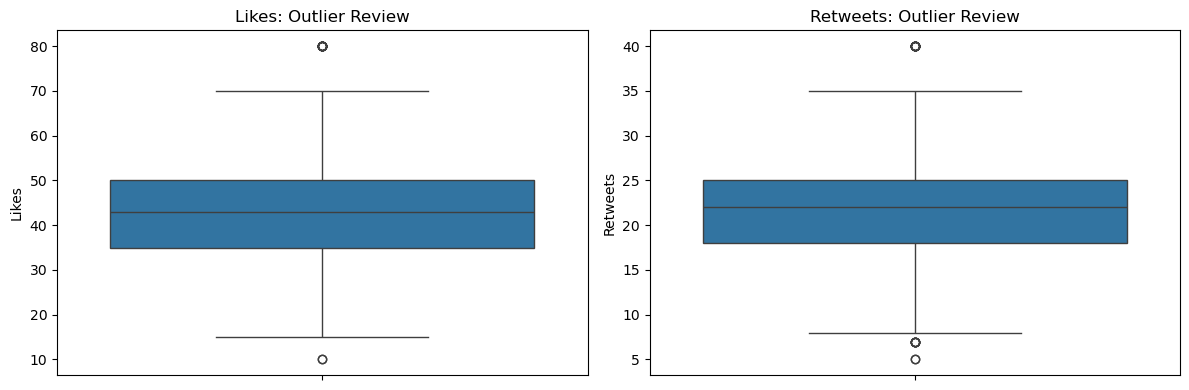

In [48]:
def iqr_summary(series):
    s = series.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return pd.Series({
        "Q1": q1, "Q3": q3, "IQR": iqr,
        "lower_bound": lower, "upper_bound": upper,
        "outlier_count": ((s < lower) | (s > upper)).sum()
    })

display(pd.DataFrame({
    "Likes": iqr_summary(df["Likes"]),
    "Retweets": iqr_summary(df["Retweets"])
}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df["Likes"], ax=axes[0])
axes[0].set_title("Likes: Outlier Review")
sns.boxplot(y=df["Retweets"], ax=axes[1])
axes[1].set_title("Retweets: Outlier Review")
plt.tight_layout()
plt.show()

# Important: IQR flags are investigation candidates, not automatic deletion rules.
# Viral posts may be legitimate observations.

## 11. Create Total Engagement

In [49]:
df["Total_Engagement"] = df["Likes"] + df["Retweets"]

display(df[["Likes", "Retweets", "Total_Engagement"]].head())

print("Missing Total_Engagement:", df["Total_Engagement"].isna().sum())

,Likes,Retweets,Total_Engagement
0,30.0,15.0,45.0
1,10.0,5.0,15.0
2,40.0,20.0,60.0
3,15.0,8.0,23.0
4,25.0,12.0,37.0


Missing Total_Engagement: 0


## 12. Clean and transform hashtags

In [50]:
# Normalize hashtag text.
df["Hashtags"] = df["Hashtags"].fillna("").astype("string").str.strip()

# Convert a row such as '#Nature #Park' into a list of normalized hashtags.
df["Hashtag_List"] = (
    df["Hashtags"]
    .str.findall(r"#\w+")
    .apply(lambda tags: [t.lower() for t in tags])
)

df["Hashtag_Count"] = df["Hashtag_List"].str.len()

display(df[["Hashtags", "Hashtag_List", "Hashtag_Count"]].head())

,Hashtags,Hashtag_List,Hashtag_Count
0,#Nature #Park,"[#nature, #park]",2
1,#Traffic #Morning,"[#traffic, #morning]",2
2,#Fitness #Workout,"[#fitness, #workout]",2
3,#Travel #Adventure,"[#travel, #adventure]",2
4,#Cooking #Food,"[#cooking, #food]",2


In [51]:
# Explode hashtags so each hashtag becomes one observation.
hashtag_df = df[["Hashtag_List"]].explode("Hashtag_List").dropna()
hashtag_df = hashtag_df.rename(columns={"Hashtag_List": "Hashtag"})

top_hashtags = hashtag_df["Hashtag"].value_counts().head(20)
display(top_hashtags)

Hashtag
#serenity         15
#excitement       13
#gratitude        12
#despair          11
#nostalgia        11
#curiosity        10
#awe               9
#contentment       9
#grief             9
#enthusiasm        8
#loneliness        8
#confusion         8
#acceptance        8
#joy               8
#determination     7
#elation           7
#euphoria          7
#reflection        6
#regret            6
#melancholy        6
Name: count, dtype: int64

## 13. Prepare text

In [52]:
df["Text"] = df["Text"].fillna("").astype("string").str.strip()

# Basic text features for EDA; this is not yet NLP classification.
df["Word_Count"] = df["Text"].str.split().str.len()
df["Character_Count"] = df["Text"].str.len()

display(df[["Text", "Word_Count", "Character_Count"]].head())
display(df[["Word_Count", "Character_Count"]].describe())

,Text,Word_Count,Character_Count
0,Enjoying a beautiful day at the park!,7,37
1,Traffic was terrible this morning.,5,34
2,Just finished an amazing workout! 💪,6,35
3,Excited about the upcoming weekend getaway!,6,43
4,Trying out a new recipe for dinner tonight.,8,43


,Word_Count,Character_Count
count,710.000000,710.0
mean,13.085915,83.691549
std,4.850917,31.220257
min,4.000000,27.0
25%,9.000000,56.0
50%,13.000000,81.5
75%,17.000000,104.0
max,25.000000,156.0


## 14. EDA

The EDA is organized around questions rather than charts for their own sake.

### 14.1 Sentiment distribution

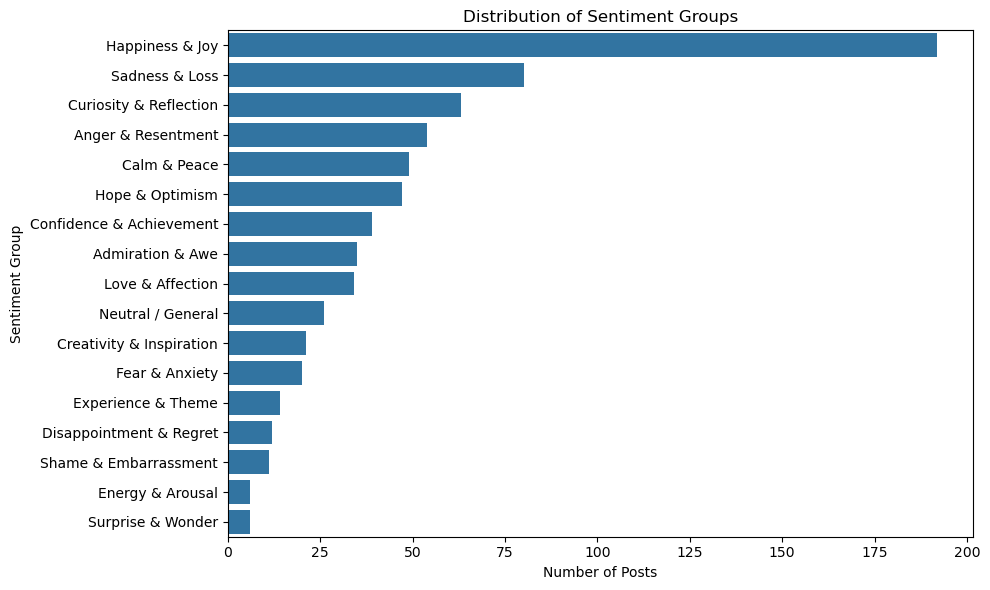

In [53]:
sentiment_counts = df["Sentiment_Group"].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=sentiment_counts.values, y=sentiment_counts.index)
plt.title("Distribution of Sentiment Groups")
plt.xlabel("Number of Posts")
plt.ylabel("Sentiment Group")
plt.tight_layout()
plt.show()

### 14.2 Engagement by sentiment

,count,mean,median,sum
Sentiment_Group,,,,
Experience & Theme,14,87.285714,90.0,1222.0
Admiration & Awe,35,75.542857,75.0,2644.0
Calm & Peace,49,72.816327,75.0,3568.0
Confidence & Achievement,39,71.205128,67.0,2777.0
Happiness & Joy,192,68.973958,67.0,13243.0
Energy & Arousal,6,68.666667,60.0,412.0
Surprise & Wonder,6,67.666667,75.0,406.0
Creativity & Inspiration,21,65.238095,60.0,1370.0
Hope & Optimism,47,64.063830,60.0,3011.0


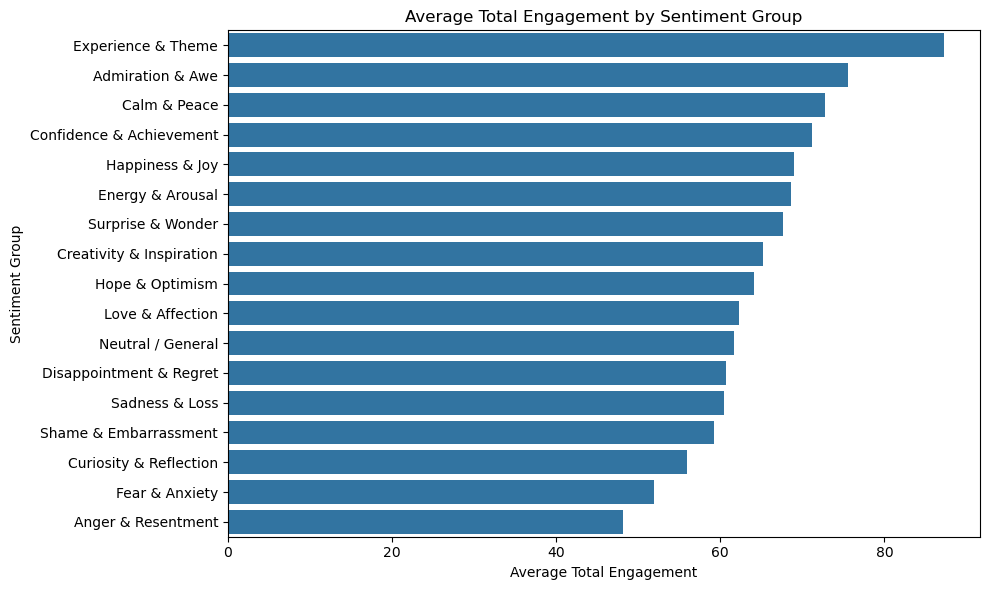

In [54]:
engagement_by_sentiment = (
    df.groupby("Sentiment_Group")["Total_Engagement"]
      .agg(["count", "mean", "median", "sum"])
      .sort_values("mean", ascending=False)
)

display(engagement_by_sentiment)

plt.figure(figsize=(10, 6))
order = engagement_by_sentiment.index
sns.barplot(data=df, y="Sentiment_Group", x="Total_Engagement", estimator="mean", order=order, errorbar=None)
plt.title("Average Total Engagement by Sentiment Group")
plt.xlabel("Average Total Engagement")
plt.ylabel("Sentiment Group")
plt.tight_layout()
plt.show()

### 14.3 Platform distribution and sentiment by platform

Platform
Instagram    251
Twitter      236
Facebook     223
Name: count, dtype: Int64

Sentiment_Group,Admiration & Awe,Anger & Resentment,Calm & Peace,Confidence & Achievement,Creativity & Inspiration,Curiosity & Reflection,Disappointment & Regret,Energy & Arousal,Experience & Theme,Fear & Anxiety,Happiness & Joy,Hope & Optimism,Love & Affection,Neutral / General,Sadness & Loss,Shame & Embarrassment,Surprise & Wonder
Platform,,,,,,,,,,,,,,,,,
Facebook,4.0,7.2,6.7,6.3,1.3,9.0,0.9,0.4,0.9,3.6,31.8,6.3,4.5,3.6,11.2,1.8,0.4
Instagram,6.4,7.2,6.0,4.0,2.4,9.6,1.6,0.8,1.2,2.8,29.1,6.4,5.2,4.0,10.8,1.2,1.6
Twitter,4.3,8.5,8.1,6.4,5.1,8.1,2.6,1.3,3.8,2.1,20.4,7.2,4.7,3.4,11.9,1.7,0.4


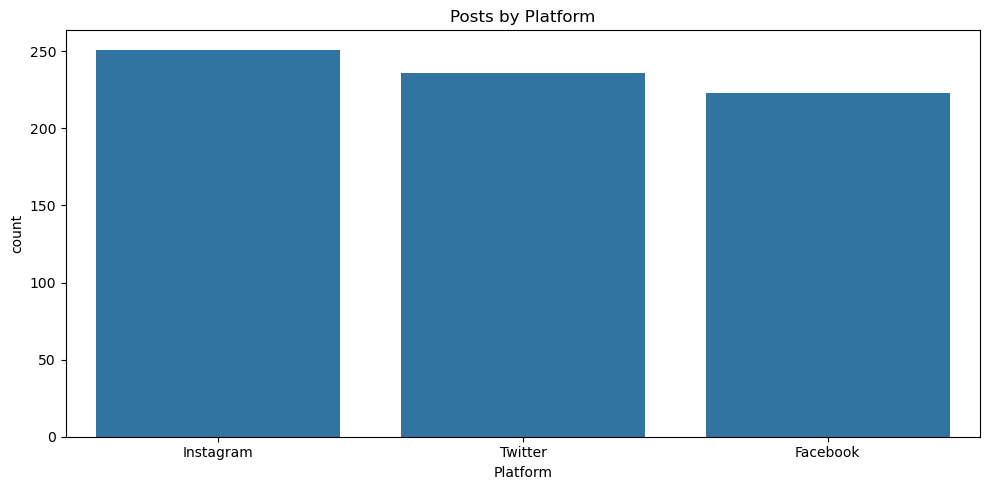

In [55]:
display(df["Platform"].value_counts())

platform_sentiment = pd.crosstab(df["Platform"], df["Sentiment_Group"], normalize="index") * 100
display(platform_sentiment.round(1))

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Platform", order=df["Platform"].value_counts().index)
plt.title("Posts by Platform")
plt.tight_layout()
plt.show()

### 14.4 Engagement by platform

,count,mean,median,sum
Platform,,,,
Instagram,251,67.916335,67.0,17047.0
Facebook,223,62.820628,67.0,14009.0
Twitter,236,62.546610,60.0,14761.0


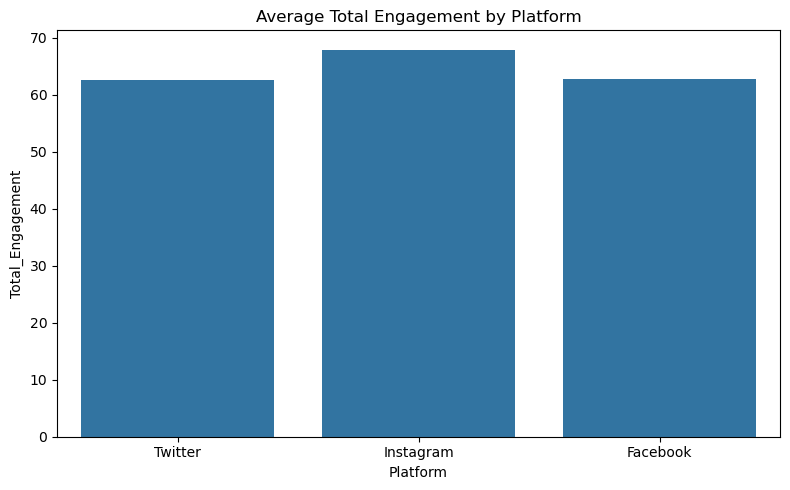

In [56]:
platform_engagement = (
    df.groupby("Platform")["Total_Engagement"]
      .agg(["count", "mean", "median", "sum"])
      .sort_values("mean", ascending=False)
)
display(platform_engagement)

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Platform", y="Total_Engagement", estimator="mean", errorbar=None)
plt.title("Average Total Engagement by Platform")
plt.tight_layout()
plt.show()

### 14.5 Country and continent analysis
The original notebook maps countries to continents. This is retained, but the analysis should avoid over-interpreting countries with very small sample sizes.

,count,mean,median,sum
Continent,,,,
Africa,7,101.714286,105.0,712.0
South America,19,79.684211,75.0,1514.0
Europe,210,64.980952,67.0,13646.0
North America,316,64.550633,62.5,20398.0
Asia,88,62.079545,60.0,5463.0
Oceania,70,58.342857,54.0,4084.0


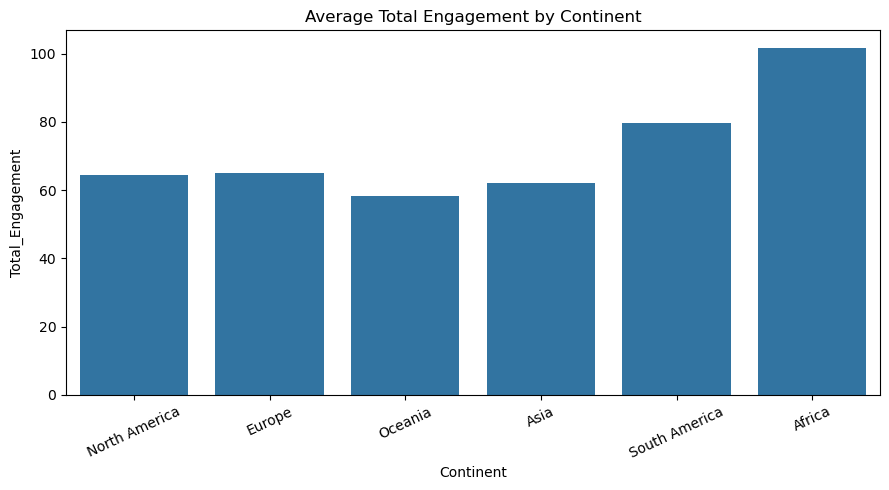

In [57]:
continent_groups = {'USA': 'North America', 'Canada': 'North America', 'Jamaica': 'North America', 'Brazil': 'South America', 'Peru': 'South America', 'Colombia': 'South America', 'UK': 'Europe', 'France': 'Europe', 'Germany': 'Europe', 'Greece': 'Europe', 'Sweden': 'Europe', 'Italy': 'Europe', 'Netherlands': 'Europe', 'Spain': 'Europe', 'Portugal': 'Europe', 'Switzerland': 'Europe', 'Austria': 'Europe', 'Belgium': 'Europe', 'Denmark': 'Europe', 'Czech Republic': 'Europe', 'Norway': 'Europe', 'Ireland': 'Europe', 'Scotland': 'Europe', 'India': 'Asia', 'Japan': 'Asia', 'Jordan': 'Asia', 'Maldives': 'Asia', 'China': 'Asia', 'Cambodia': 'Asia', 'Thailand': 'Asia', 'South Africa': 'Africa', 'Kenya': 'Africa', 'Australia': 'Oceania'}
df["Continent"] = df["Country"].map(continent_groups)

# print("Countries without a continent mapping:")
# display(df.loc[df["Continent"].isna(), "Country"].value_counts())

continent_summary = (
    df.groupby("Continent")["Total_Engagement"]
      .agg(["count", "mean", "median", "sum"])
      .sort_values("mean", ascending=False)
)
display(continent_summary)

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Continent", y="Total_Engagement", estimator="mean", errorbar=None)
plt.title("Average Total Engagement by Continent")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

### 14.6 Time analysis

,count,mean,median
Hour,,,
0,1,53.000000,53.0
2,1,54.000000,54.0
3,2,54.000000,54.0
5,1,83.000000,83.0
6,3,55.666667,42.0
7,6,64.666667,60.0
8,21,60.619048,60.0
9,27,55.148148,60.0
10,29,62.724138,54.0


,count,mean,median
Month,,,
1,78,56.884615,53.0
2,85,61.858824,60.0
3,44,63.909091,60.0
4,49,64.183673,67.0
5,45,63.155556,67.0
6,70,71.071429,67.0
7,60,74.400000,71.0
8,75,65.906667,66.0
9,74,62.608108,60.0


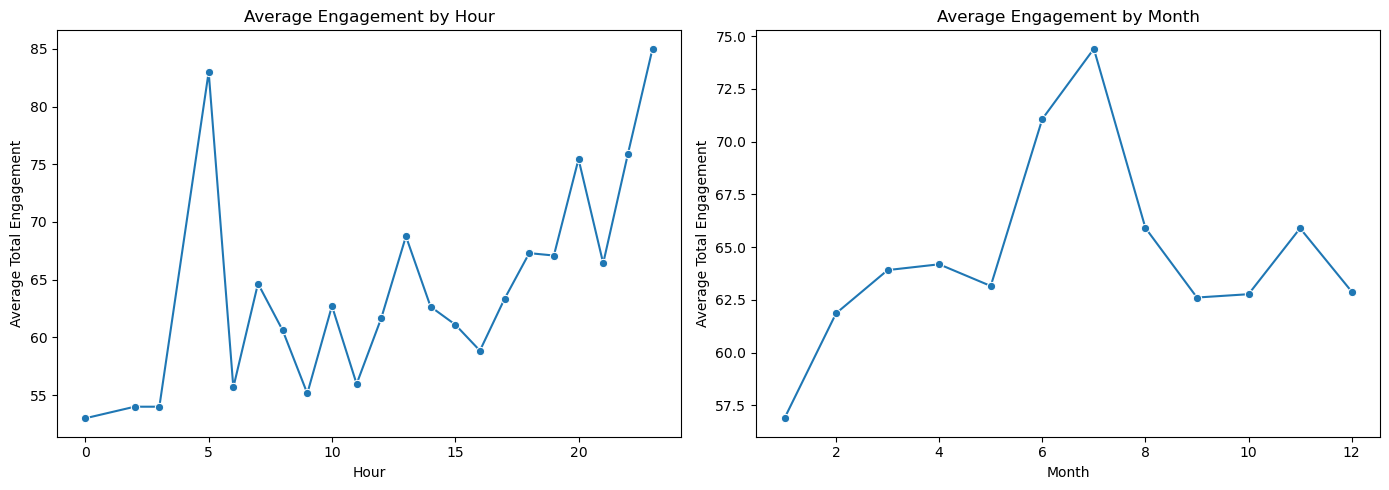

In [58]:
hour_summary = df.groupby("Hour")["Total_Engagement"].agg(["count", "mean", "median"]).sort_index()
month_summary = df.groupby("Month")["Total_Engagement"].agg(["count", "mean", "median"]).sort_index()

display(hour_summary)
display(month_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=hour_summary, x=hour_summary.index, y="mean", marker="o", ax=axes[0])
axes[0].set_title("Average Engagement by Hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Average Total Engagement")

sns.lineplot(data=month_summary, x=month_summary.index, y="mean", marker="o", ax=axes[1])
axes[1].set_title("Average Engagement by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average Total Engagement")

plt.tight_layout()
plt.show()

### 14.7 Likes vs Retweets

,Likes,Retweets
Likes,1.00000,0.99847
Retweets,0.99847,1.00000


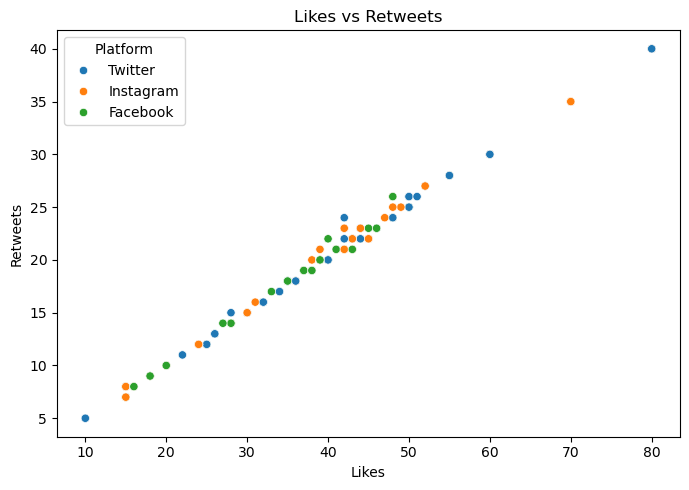

In [59]:
display(df[["Likes", "Retweets"]].corr())

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Likes", y="Retweets", hue="Platform")
plt.title("Likes vs Retweets")
plt.tight_layout()
plt.show()

### 14.8 Hashtag analysis

In [60]:
hashtag_engagement = (
    df[["Hashtag_List", "Total_Engagement"]]
    .explode("Hashtag_List")
    .dropna()
    .rename(columns={"Hashtag_List": "Hashtag"})
    .groupby("Hashtag")
    .agg(post_count=("Hashtag", "size"),
         avg_engagement=("Total_Engagement", "mean"),
         median_engagement=("Total_Engagement", "median"))
    .query("post_count >= 3")
    .sort_values("avg_engagement", ascending=False)
)

display(hashtag_engagement.head(20))

,post_count,avg_engagement,median_engagement
Hashtag,,,
#wonder,3,110.000000,120.0
#thrill,4,93.750000,94.0
#joy,8,92.750000,94.0
#fitnessgoals,3,90.000000,83.0
#harmony,3,87.666667,105.0
#personalgrowth,3,85.000000,75.0
#happiness,5,84.000000,90.0
#enchantment,4,82.500000,82.5
#excitement,13,80.076923,75.0


### 14.9 Text length vs engagement

,Word_Count,Character_Count,Total_Engagement
Word_Count,1.000000,0.947763,0.209867
Character_Count,0.947763,1.000000,0.214043
Total_Engagement,0.209867,0.214043,1.000000


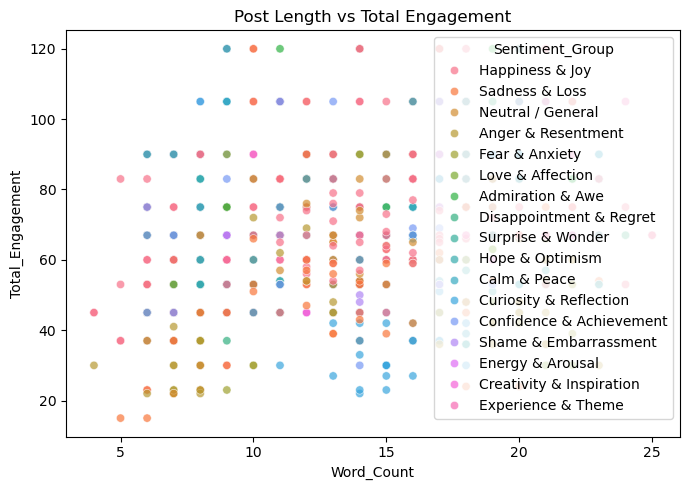

In [61]:
text_summary = df[["Word_Count", "Character_Count", "Total_Engagement"]].corr()
display(text_summary)

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Word_Count", y="Total_Engagement", hue="Sentiment_Group", alpha=0.7)
plt.title("Post Length vs Total Engagement")
plt.tight_layout()
plt.show()

## 15. Insights

Use the tables and charts above to write evidence-based findings. Do **not** invent conclusions before running the notebook.

A strong insight should contain:
- **Finding:** what the data shows
- **Evidence:** count, mean, median, percentage, or comparison
- **Interpretation:** what it could mean
- **Caveat:** sample size or data limitation when relevant

### Example structure
> The "Experience and theme" sentiment group recorded the highest average total engagement at approximately 93 engagements, while "Anger and Resentment" had the lowest at approximately 47 engagements. This suggests posts positivity. However, the result should be interpreted alongside post counts and outliers because engagement is highly variable.

### Important caution
A higher average engagement does **not** prove that sentiment causes engagement. This project is observational and supports association/trend analysis, not causal claims.

## 16. Recommendations

Recommendations must follow the actual findings. Possible recommendation areas include:

1. **Content strategy:** prioritize emotional/content themes depicting happiness and joy, that consistently show strong engagement.
2. **Platform strategy:** tailor content by platform when engagement or sentiment composition differs materially.
3. **Timing strategy:** test posting during high-engagement time windows.
4. **Hashtag strategy:** evaluate frequently occurring hashtags alongside their engagement performance.
5. **Data quality:** continue validating timestamps, categories, missing values, and extreme engagement records.
6. **Further analysis:** Results investigations remain constant across platforms, engagements and countries

### Limitations
- The dataset is observational.
- Engagement may be influenced by factors not included in the data.
- Some countries have very small sample sizes, so country-level averages can be unstable.
- IQR outliers are not automatically errors; viral posts can be legitimate.
- `Sentiment_Group` is a manually defined analytical grouping based on the source labels.

## Final dataset quality check

Before exporting the cleaned dataset, run the following audit.

In [62]:
# Columns containing list/dictionary/set objects cannot be used directly
# in pandas duplicate detection.
def is_hashable_value(x):
    try:
        hash(x)
        return True
    except TypeError:
        return False


duplicate_check_cols = []

for col in df.columns:
    if df[col].map(is_hashable_value).all():
        duplicate_check_cols.append(col)

print("Columns used for duplicate checking:")
print(duplicate_check_cols)

duplicate_count = df.duplicated(
    subset=duplicate_check_cols,
    keep=False
).sum()

print(f"\nDuplicate rows found: {duplicate_count}")

final_audit = pd.DataFrame({
    "rows": [len(df)],
    "columns": [df.shape[1]],
    "duplicate_rows": [
        df.duplicated(subset=duplicate_check_cols).sum()
    ],
    "missing_cells": [
        df.isna().sum().sum()
    ],
    "negative_likes": [
        (df["Likes"] < 0).sum()
    ],
    "negative_retweets": [
        (df["Retweets"] < 0).sum()
    ],
    "unmapped_sentiment_groups": [
        df["Sentiment_Group"].isna().sum()
    ],
    "unmapped_continents": [
        df["Continent"].isna().sum()
    ]
})

display(final_audit)

# duplicate_check_cols = [
#     col for col in df.columns
#     if not df[col].apply(lambda x: isinstance(x, list)).any()
# ]

# final_audit = pd.DataFrame({
#     "rows": [len(df)],
#     "columns": [df.shape[1]],
#     "duplicate_rows": [df.duplicated(subset=duplicate_check_cols).sum()],
#     "missing_cells": [df.isna().sum().sum()],
#     "negative_likes": [(df["Likes"] < 0).sum()],
#     "negative_retweets": [(df["Retweets"] < 0).sum()],
#     "unmapped_sentiment_groups": [df["Sentiment_Group"].isna().sum()],
#     "unmapped_continents": [df["Continent"].isna().sum()]
# })

# display(final_audit)


df.to_csv("data/sentiment_cleaned.csv", index=False)

Columns used for duplicate checking:
['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour', 'Sentiment_Group', 'Total_Engagement', 'Hashtag_Count', 'Word_Count', 'Character_Count', 'Continent']

Duplicate rows found: 0


,rows,columns,duplicate_rows,missing_cells,negative_likes,negative_retweets,unmapped_sentiment_groups,unmapped_continents
0,710,20,0,1,0,0,1,0


In [63]:
df['Timestamp'].min()
# df.columns

Timestamp('2010-05-15 15:30:00')

In [64]:
hashtag_tableau = (
    df[['Hashtag_List', 'Total_Engagement']]
    .explode('Hashtag_List')
    .dropna(subset=['Hashtag_List'])
    .rename(columns={'Hashtag_List': 'Hashtag'})
)

hashtag_tableau.to_csv(
    "../data/hashtag_analysis.csv",
    index=False
)

hashtag_tableau

,Hashtag,Total_Engagement
0,#nature,45.0
0,#park,45.0
1,#traffic,15.0
1,#morning,15.0
2,#fitness,60.0
...,...,...
729,#highschoolphilanthropy,64.0
730,#culturalcelebration,64.0
730,#highschoolunity,64.0
731,#virtualentertainment,71.0
